<a href="https://colab.research.google.com/github/PihuCodeTech/Aircraft-Engine-RUL-Prediction/blob/main/notebooks/rul_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
#Imports

import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error , accuracy_score , precision_score , recall_score , f1_score , confusion_matrix , classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential , Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, LSTM, GRU, Dropout, BatchNormalization, Bidirectional, Attention, GlobalAveragePooling1D, LayerNormalization,  MultiHeadAttention, Add ,Multiply, LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


In [25]:
#Data Loading and Preprocessing

# Load training data
train_df = pd.read_csv("train_FD001.txt", sep=r"\s+", header=None)
train_df.columns = ['id', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]

# Compute Remaining Useful Life (RUL)
max_cycle = train_df.groupby('id')['cycle'].max().reset_index().rename(columns={'cycle': 'max_cycle'})
train_df = train_df.merge(max_cycle, on='id')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df.drop(columns=['max_cycle'], inplace=True)

# Cap RUL values for stability
train_df['RUL'] = train_df['RUL'].clip(upper=125)

# Separate features and target
feature_cols = [col for col in train_df.columns if col not in ['id', 'RUL']]
X = train_df[feature_cols].copy()
y = train_df['RUL'].copy()

# Standardize features
scaler = StandardScaler()
X[feature_cols] = scaler.fit_transform(X[feature_cols])


In [26]:
# SEQUENCE CREATION

processed_df = X.copy()
processed_df['RUL'] = y.values
processed_df['id'] = train_df['id'].values

sequence_length = 30
engine_ids = processed_df['id'].unique()
train_engine_ids, val_engine_ids = train_test_split(
    engine_ids, test_size=0.20, random_state=SEED
)
train_df_split = processed_df[processed_df['id'].isin(train_engine_ids)]
val_df_split = processed_df[processed_df['id'].isin(val_engine_ids)]

# Sequence Creation Function
def create_sequences(df, sequence_length):
    X_seqs, y_seqs = [], []
    for engine_id in df['id'].unique():
        engine_data = df[df['id'] == engine_id].drop(columns=['id'])
        data_array = engine_data.values
        for i in range(len(data_array) - sequence_length):
            X_seqs.append(data_array[i:i+sequence_length, :-1])
            y_seqs.append(data_array[i+sequence_length, -1])
    return np.array(X_seqs), np.array(y_seqs)

# Create Train and Validation Sequences
X_train, y_train = create_sequences(train_df_split, sequence_length)
X_val, y_val = create_sequences(val_df_split, sequence_length)

print(f"Shape of X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shape of X_val:   {X_val.shape}, y_val:   {y_val.shape}")


Shape of X_train: (14161, 30, 25), y_train: (14161,)
Shape of X_val:   (3470, 30, 25), y_val:   (3470,)


In [27]:
# Callbacks
callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.8, patience=5, min_lr=1e-5, verbose=1)
]

callbacks_rnn = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.8, patience=6, min_lr=1e-6, verbose=1)
]


In [28]:
# 1. Improved BiLSTM + Attention

lstm_inputs = Input(shape=(sequence_length, X_train.shape[2]))

lstm_x = Bidirectional(
    LSTM(
        64,
        return_sequences=True,
        recurrent_dropout=0.05
    )
)(lstm_inputs)

# REMOVE BatchNorm
lstm_x = Dropout(0.1)(lstm_x)

# MultiHead Self Attention
attention_output = MultiHeadAttention(
    num_heads=4,
    key_dim=32,
    dropout=0.05
)(lstm_x, lstm_x)

# Residual connection
lstm_x = Add()([lstm_x, attention_output])
lstm_x = LayerNormalization()(lstm_x)

# Feed Forward Network
ffn = Dense(128, activation='relu')(lstm_x)
ffn = Dense(lstm_x.shape[-1])(ffn)

# Residual connection
lstm_x = Add()([lstm_x, ffn])
lstm_x = LayerNormalization()(lstm_x)

# Pooling
lstm_x = GlobalAveragePooling1D()(lstm_x)

# Dense layers
lstm_x = Dense(64, activation='relu')(lstm_x)

# LOWER dropout
lstm_x = Dropout(0.1)(lstm_x)

lstm_outputs = Dense(1)(lstm_x)

lstm_model = Model(lstm_inputs, lstm_outputs)

lstm_model.compile(
    optimizer=Adam(8e-5),
    loss=Huber(),
    metrics=['mae']
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=64,
    callbacks=callbacks_rnn,
    verbose=1
)

Epoch 1/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 48s 163ms/step - loss: 69.3971 - mae: 69.8951 - val_loss: 57.2751 - val_mae: 57.7730 - learning_rate: 8.0000e-05
Epoch 2/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 35s 159ms/step - loss: 48.7102 - mae: 49.2060 - val_loss: 38.9635 - val_mae: 39.4583 - learning_rate: 8.0000e-05
Epoch 3/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 34s 154ms/step - loss: 32.3872 - mae: 32.8801 - val_loss: 24.3536 - val_mae: 24.8443 - learning_rate: 8.0000e-05
Epoch 4/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 42s 160ms/step - loss: 20.5369 - mae: 21.0285 - val_loss: 15.0328 - val_mae: 15.5222 - learning_rate: 8.0000e-05
Epoch 5/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 42s 162ms/step - loss: 13.5952 - mae: 14.0852 - val_loss: 10.0676 - val_mae: 10.5557 - learning_rate: 8.0000e-05
Epoch 6/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 36s 160ms/step - loss: 10.6438 - mae: 11.1294 - val_loss: 8.2534 - val_mae: 8.7379 - learning_rate: 8.0000e-05
Epoch 7/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 41s 162ms/step - loss: 9.6310 - mae: 10.1146

In [29]:
# 2. CNN + Attention
cnn_inputs = Input(shape=(sequence_length, X_train.shape[2]))
cnn_x = Conv1D(64, kernel_size=3, activation='relu')(cnn_inputs)
cnn_x = BatchNormalization()(cnn_x)
cnn_x = MaxPooling1D(pool_size=2)(cnn_x)
cnn_x = Dropout(0.2)(cnn_x)
cnn_x = Conv1D(32, kernel_size=3, activation='relu')(cnn_x)
cnn_x = BatchNormalization()(cnn_x)
attention_weights = Dense(32, activation='softmax')(cnn_x)
cnn_attention = Multiply()([cnn_x, attention_weights])
cnn_x = Flatten()(cnn_attention)
cnn_x = Dense(64, activation='relu')(cnn_x)
cnn_x = Dropout(0.3)(cnn_x)
cnn_outputs = Dense(1)(cnn_x)
cnn_model = Model(cnn_inputs, cnn_outputs)
cnn_model.compile(optimizer=Adam(1e-3), loss=Huber(), metrics=['mae'])
history_cnn = cnn_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=60, batch_size=64, callbacks=callbacks_cnn, verbose=1)


Epoch 1/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 48.8376 - mae: 49.3338 - val_loss: 17.0693 - val_mae: 17.5632 - learning_rate: 0.0010
Epoch 2/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 16.1095 - mae: 16.6016 - val_loss: 12.5710 - val_mae: 13.0641 - learning_rate: 0.0010
Epoch 3/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 13.6584 - mae: 14.1490 - val_loss: 12.6033 - val_mae: 13.0953 - learning_rate: 0.0010
Epoch 4/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 12.5597 - mae: 13.0490 - val_loss: 12.1668 - val_mae: 12.6585 - learning_rate: 0.0010
Epoch 5/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 11.7842 - mae: 12.2730 - val_loss: 12.6037 - val_mae: 13.0965 - learning_rate: 0.0010
Epoch 6/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 11.5132 - mae: 12.0025 - val_loss: 11.6444 - val_mae: 12.1363 - learning_rate: 0.0010
Epoch 7/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 11.0711 - mae: 11.5593 - val_loss: 11.9297 - val_mae: 12.

109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step

=== VALIDATION RESULTS ===
CNN + Attention: MSE=298.424, RMSE=17.275, MAE=11.767
BiLSTM + Attention: MSE=159.933, RMSE=12.646, MAE=8.436
Ensemble: MSE=162.573, RMSE=12.750, MAE=8.574
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

=== TEST RESULTS ===
CNN + Attention: MSE=462.006, RMSE=21.494, MAE=15.262
BiLSTM + Attention: MSE=198.584, RMSE=14.092, MAE=10.176
Ensemble: MSE=203.265, RMSE=14.257, MAE=10.220

=== SAMPLE PREDICTIONS ===

Engine 1
Actual RUL      : 112.0
BiLSTM Predicted: 123.4
Ensemble Predicted: 123.3
----------------------------------------
Engine 2
Actual RUL      : 98.0
BiLSTM Predicted: 123.6
Ensemble Predicted: 123.4
----------------------------------------
Engine 3
Actual RUL      : 69.0
BiLSTM Predicted: 45.6
Ensemble Predicted: 46.2
----------------------------------------
Engine 4
Actual RUL      : 82.0
BiLSTM Predicted: 88.3
Ensemble Predicted: 89.2


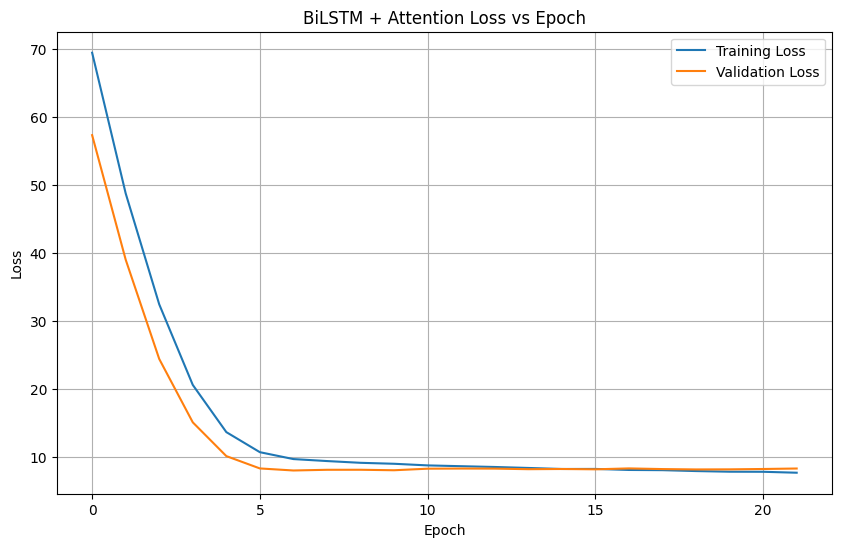

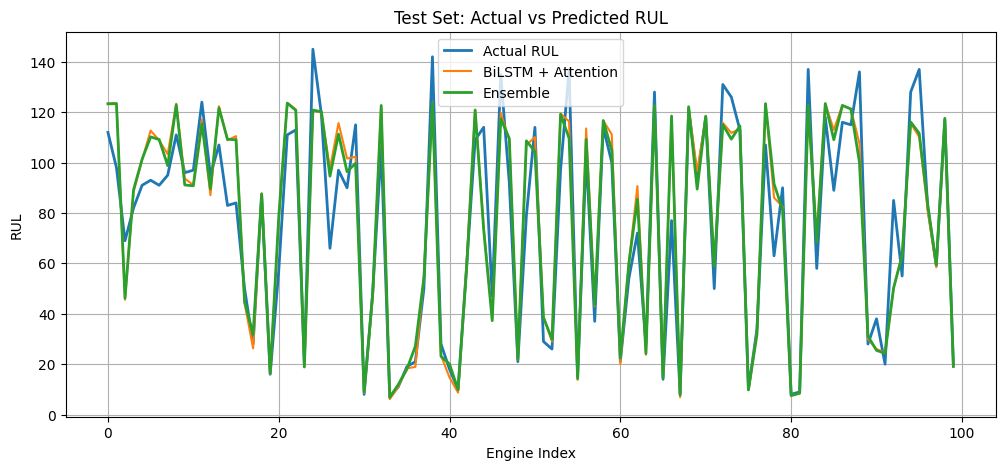

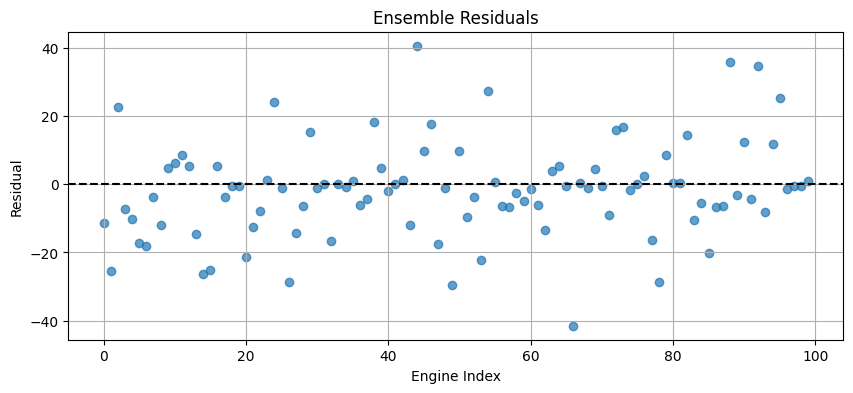

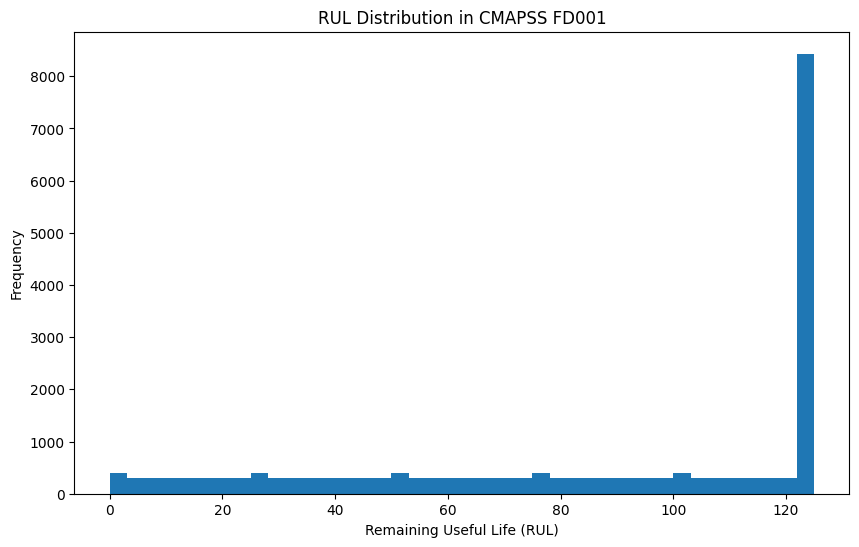

In [30]:
# =========================================
# EVALUATION AND VISUALIZATION
# =========================================

# Validation Predictions
y_pred_cnn = cnn_model.predict(X_val).flatten()
y_pred_lstm = lstm_model.predict(X_val).flatten()

# Ensemble Prediction
ensemble_pred_val = 0.85 * y_pred_lstm + 0.15 * y_pred_cnn

# Metrics Function
def report_metrics(name, true, pred):
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true, pred)
    print(f"{name}: MSE={mse:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}")

# Validation Results
print("\n=== VALIDATION RESULTS ===")
report_metrics("CNN + Attention", y_val, y_pred_cnn)
report_metrics("BiLSTM + Attention", y_val, y_pred_lstm)
report_metrics("Ensemble", y_val, ensemble_pred_val)

# TEST SET EVALUATION

# Load and preprocess test data
test_df = pd.read_csv("test_FD001.txt", sep=r"\s+", header=None).iloc[:, :26]
test_df.columns = ['id','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

# Build test sequences
X_test = []
for engine_id in test_df['id'].unique():
    engine_data = test_df[test_df['id'] == engine_id][feature_cols].values
    X_test.append(engine_data[-sequence_length:])
X_test = np.array(X_test)

# Load true RUL
y_test = pd.read_csv(
    "RUL_FD001.txt",
    header=None
).values.flatten()

# Test Predictions
pred_cnn = cnn_model.predict(X_test).flatten()
pred_lstm = lstm_model.predict(X_test).flatten()

# Ensemble
ensemble_pred_test = ( 0.85 * pred_lstm + 0.15 * pred_cnn)

# TEST RESULTS
print("\n=== TEST RESULTS ===")
report_metrics("CNN + Attention", y_test, pred_cnn)
report_metrics("BiLSTM + Attention", y_test, pred_lstm)
report_metrics("Ensemble", y_test, ensemble_pred_test)

# SAMPLE PREDICTIONS
print("\n=== SAMPLE PREDICTIONS ===\n")
for i in range(5):
    print(f"Engine {i+1}")
    print(f"Actual RUL      : {y_test[i]:.1f}")
    print(f"BiLSTM Predicted: {pred_lstm[i]:.1f}")
    print(f"Ensemble Predicted: {ensemble_pred_test[i]:.1f}")
    print("-" * 40)

# BiLSTM ( LOSS VS EPOCH )
plt.figure(figsize=(10,6))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('BiLSTM + Attention Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

# FINAL PLOT
plt.figure(figsize=(12,5))
plt.plot(y_test, label='Actual RUL', linewidth=2)
plt.plot(pred_lstm, label='BiLSTM + Attention', linewidth=1.5)
plt.plot(ensemble_pred_test, label='Ensemble', linewidth=2)
plt.title('Test Set: Actual vs Predicted RUL')
plt.xlabel('Engine Index')
plt.ylabel('RUL')
plt.legend()
plt.grid()
plt.show()

# RESIDUAL PLOT
ensemble_residuals = y_test - ensemble_pred_test
plt.figure(figsize=(10,4))
plt.scatter(range(len(ensemble_residuals)), ensemble_residuals, alpha=0.7)
plt.axhline(y=0, linestyle='--', color='black')
plt.title('Ensemble Residuals')
plt.xlabel('Engine Index')
plt.ylabel('Residual')
plt.grid()
plt.show()

# RUL DISTRIBUTION PLOT
plt.figure(figsize=(10,6))
plt.hist(train_df['RUL'], bins=40)
plt.xlabel("Remaining Useful Life (RUL)")
plt.ylabel("Frequency")
plt.title("RUL Distribution in CMAPSS FD001")
plt.show()
